In [57]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import torch as t
import torch.nn as nn
import torch.optim as optim
import numpy as np
from cuml.manifold.umap import UMAP
from cuml import TSNE

In [3]:
data=pd.read_table("../data/datasets/scivis/alloy_data.txt")
data.describe()

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136
count,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,16.500000,16.500000,16.500000,16.500000,16.500000,17.500000,91.024760,4.710985,1.633425,0.569050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.276055,15.276055,15.276055,15.276055,15.276055,15.276055,2.835679,2.273711,0.730324,0.329574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,79.966460,0.716500,0.058500,0.013000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.300000,3.300000,3.300000,3.300000,3.300000,4.300000,89.113631,2.873941,1.072590,0.311980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13.200000,13.200000,13.200000,13.200000,13.200000,14.200000,91.267046,4.399894,1.554225,0.527800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,23.100000,23.100000,23.100000,23.100000,23.100000,24.100000,93.164818,6.259213,2.118360,0.782725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,99.000000,99.000000,99.000000,99.000000,99.000000,100.000000,97.168700,12.695500,4.612500,2.012800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136
0,0.0,0.0,0.0,0.0,0.0,100.0,83.675000,12.250000,0.900000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,3.3,96.7,84.118850,11.865550,0.874425,1.257100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,6.6,93.4,84.562700,11.481100,0.848850,1.214200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,9.9,90.1,85.006550,11.096650,0.823275,1.171300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,13.2,86.8,85.450400,10.712200,0.797700,1.128400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324627,95.7,0.0,0.0,0.0,3.3,1.0,80.533928,12.296200,3.381765,1.946140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324628,95.7,0.0,0.0,3.3,0.0,1.0,80.539868,12.297322,3.397440,1.946140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324629,95.7,0.0,3.3,0.0,0.0,1.0,80.521553,12.309400,3.379290,1.946965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324630,95.7,3.3,0.0,0.0,0.0,1.0,80.358533,12.297025,3.531090,1.946965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(data.columns.to_list())

['KS1295[%]', '6082[%]', '2024[%]', 'bat-box[%]', '3003[%]', '4032[%]', 'Al', 'Si', 'Cu', 'Ni', 'Mg', 'Mn', 'Fe', 'Cr', 'Ti', 'Zr', 'V', 'Zn', 'Vf_FCC_A1', 'Vf_DIAMOND_A4', 'Vf_AL15SI2M4', 'Vf_AL3X', 'Vf_AL6MN', 'Vf_MG2ZN3', 'Vf_AL3NI2', 'Vf_AL3NI_D011', 'Vf_AL7CU4NI', 'Vf_AL2CU_C16', 'Vf_Q_ALCUMGSI', 'Vf_AL7CU2FE', 'Vf_MG2SI_C1', 'Vf_AL9FE2SI2', 'Vf_AL18FE2MG7SI10', 'eut. frac.[%]', 'eut. T (�C)', 'T_FCC_A1', 'T_DIAMOND_A4', 'T_AL15SI2M4', 'T_AL3X', 'T_AL6MN', 'T_MG2ZN3', 'T_AL3NI2', 'T_AL3NI_D011', 'T_AL7CU4NI', 'T_AL2CU_C16', 'T_Q_ALCUMGSI', 'T_AL7CU2FE', 'T_MG2SI_C1', 'T_AL9FE2SI2', 'T_AL18FE2MG7SI10', 'T(liqu)', 'T(sol)', 'delta_T', 'delta_T_FCC', 'delta_T_Al15Si2M4', 'delta_T_Si', 'CSC', 'YS(MPa)', 'hardness(Vickers)', 'CTEvol(1/K)(20.0-300.0�C)', 'Density(g/cm3)', 'Volume(m3/mol)', 'El.conductivity(S/m)', 'El. resistivity(ohm m)', 'heat capacity(J/(mol K))', 'Therm.conductivity(W/(mK))', 'Therm. diffusivity(m2/s)', 'Therm.resistivity(mK/W)', 'Linear thermal expansion (1/K)(20.0-

In [6]:
data.describe()

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136
count,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,16.500000,16.500000,16.500000,16.500000,16.500000,17.500000,91.024760,4.710985,1.633425,0.569050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.276055,15.276055,15.276055,15.276055,15.276055,15.276055,2.835679,2.273711,0.730324,0.329574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,79.966460,0.716500,0.058500,0.013000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.300000,3.300000,3.300000,3.300000,3.300000,4.300000,89.113631,2.873941,1.072590,0.311980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13.200000,13.200000,13.200000,13.200000,13.200000,14.200000,91.267046,4.399894,1.554225,0.527800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,23.100000,23.100000,23.100000,23.100000,23.100000,24.100000,93.164818,6.259213,2.118360,0.782725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,99.000000,99.000000,99.000000,99.000000,99.000000,100.000000,97.168700,12.695500,4.612500,2.012800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
input_cols= data.columns.to_list()[:6]
output_cols= data.columns.to_list()[6:70]
input_cols, output_cols

(['KS1295[%]', '6082[%]', '2024[%]', 'bat-box[%]', '3003[%]', '4032[%]'],
 ['Al',
  'Si',
  'Cu',
  'Ni',
  'Mg',
  'Mn',
  'Fe',
  'Cr',
  'Ti',
  'Zr',
  'V',
  'Zn',
  'Vf_FCC_A1',
  'Vf_DIAMOND_A4',
  'Vf_AL15SI2M4',
  'Vf_AL3X',
  'Vf_AL6MN',
  'Vf_MG2ZN3',
  'Vf_AL3NI2',
  'Vf_AL3NI_D011',
  'Vf_AL7CU4NI',
  'Vf_AL2CU_C16',
  'Vf_Q_ALCUMGSI',
  'Vf_AL7CU2FE',
  'Vf_MG2SI_C1',
  'Vf_AL9FE2SI2',
  'Vf_AL18FE2MG7SI10',
  'eut. frac.[%]',
  'eut. T (�C)',
  'T_FCC_A1',
  'T_DIAMOND_A4',
  'T_AL15SI2M4',
  'T_AL3X',
  'T_AL6MN',
  'T_MG2ZN3',
  'T_AL3NI2',
  'T_AL3NI_D011',
  'T_AL7CU4NI',
  'T_AL2CU_C16',
  'T_Q_ALCUMGSI',
  'T_AL7CU2FE',
  'T_MG2SI_C1',
  'T_AL9FE2SI2',
  'T_AL18FE2MG7SI10',
  'T(liqu)',
  'T(sol)',
  'delta_T',
  'delta_T_FCC',
  'delta_T_Al15Si2M4',
  'delta_T_Si',
  'CSC',
  'YS(MPa)',
  'hardness(Vickers)',
  'CTEvol(1/K)(20.0-300.0�C)',
  'Density(g/cm3)',
  'Volume(m3/mol)',
  'El.conductivity(S/m)',
  'El. resistivity(ohm m)',
  'heat capacity(J/(mol K))',
  

In [8]:
from col_defs import *

In [9]:
cleaned = data[input_cols + output_cols].fillna(0)
cleaned

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Density(g/cm3),Volume(m3/mol),El.conductivity(S/m),El. resistivity(ohm m),heat capacity(J/(mol K)),Therm.conductivity(W/(mK)),Therm. diffusivity(m2/s),Therm.resistivity(mK/W),Linear thermal expansion (1/K)(20.0-300.0�C),Technical thermal expansion (1/K)(20.0-300.0�C)
0,0.0,0.0,0.0,0.0,0.0,100.0,83.675000,12.250000,0.900000,1.300000,...,2.65803,0.00001,11302200,8.851450e-08,27.3373,159.046,0.000060,0.006288,0.000024,0.000022
1,0.0,0.0,0.0,0.0,3.3,96.7,84.118850,11.865550,0.874425,1.257100,...,2.65879,0.00001,11414800,8.767350e-08,27.3430,160.429,0.000061,0.006232,0.000024,0.000022
2,0.0,0.0,0.0,0.0,6.6,93.4,84.562700,11.481100,0.848850,1.214200,...,2.65935,0.00001,11489900,8.708070e-08,27.3633,161.346,0.000061,0.006203,0.000024,0.000022
3,0.0,0.0,0.0,0.0,9.9,90.1,85.006550,11.096650,0.823275,1.171300,...,2.66111,0.00001,11566400,8.646380e-08,27.3806,162.105,0.000061,0.006168,0.000024,0.000022
4,0.0,0.0,0.0,0.0,13.2,86.8,85.450400,10.712200,0.797700,1.128400,...,2.66318,0.00001,11650800,8.581640e-08,27.3873,163.127,0.000061,0.006127,0.000024,0.000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324627,95.7,0.0,0.0,0.0,3.3,1.0,80.533928,12.296200,3.381765,1.946140,...,2.72509,0.00001,10539500,9.491770e-08,27.3289,149.812,0.000056,0.006691,0.000023,0.000021
324628,95.7,0.0,0.0,3.3,0.0,1.0,80.539868,12.297322,3.397440,1.946140,...,2.72496,0.00001,10545800,9.494870e-08,27.3291,149.752,0.000056,0.006688,0.000023,0.000021
324629,95.7,0.0,3.3,0.0,0.0,1.0,80.521553,12.309400,3.379290,1.946965,...,2.72497,0.00001,10558200,9.485710e-08,27.3189,149.799,0.000056,0.006686,0.000023,0.000021
324630,95.7,3.3,0.0,0.0,0.0,1.0,80.358533,12.297025,3.531090,1.946965,...,2.72756,0.00001,10552100,9.486620e-08,27.3293,149.771,0.000056,0.006683,0.000023,0.000021


In [10]:
class MLPNetwork(nn.Module):
    def __init__(self, input_size=len(input_cols), output_size=len(output_cols), hidden_size=64, hidden_layers=2, activation=nn.ReLU):
        super(MLPNetwork, self).__init__()
        self.in_layer = nn.Linear(input_size, hidden_size)
        self.hidden_layers = nn.ModuleList()
        for _ in range(hidden_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_size, hidden_size))
        self.out_layer = nn.Linear(hidden_size, output_size)
        self.activation = activation()
        self.in_norm = nn.BatchNorm1d(input_size)
        self.out_norm= nn.BatchNorm1d(output_size)
        
    def forward(self, x):
        x = self.in_norm(x)
        x = self.activation(self.in_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.out_norm(self.out_layer(x))
        return x
    
import torch.utils.data as data_utils
from tqdm import tqdm

In [11]:
# device = "cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu"
# print(f"Using device: {device}")
# network = MLPNetwork(
#     input_size=len(input_cols),
#     output_size=len(output_cols),
#     hidden_size=128,
#     hidden_layers=4,
#     activation=nn.ReLU,
# ).to(device)
# optimizer = optim.Adam(network.parameters(), lr=0.01)
# criterion = nn.MSELoss()
# network.train()
# inputs = t.tensor(cleaned[input_cols].values, dtype=t.float32)
# targets = t.tensor(cleaned[output_cols].values, dtype=t.float32)
# dataset = data_utils.TensorDataset(inputs, targets)
# dataloader = data_utils.DataLoader(dataset, batch_size=128, shuffle=True)
# epochs = 10
# for epoch in range(epochs):
#     gen=tqdm(dataloader)
#     for batch_inputs, batch_targets in gen:
#         optimizer.zero_grad()
#         outputs = network(batch_inputs.to(device))
#         loss = criterion(outputs, batch_targets.to(device))
#         loss.backward()
#         optimizer.step()
#         gen.set_description(f"Epoch {epoch+1}/{epochs}")
#         gen.set_postfix(loss=loss.item())
#     print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

In [12]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
X = cleaned[input_cols].values
y = cleaned[output_cols].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [13]:
model_ensemble: dict[str, lgb.LGBMRegressor] = {}

for i, output_col in enumerate(tqdm(output_cols)):
    model = lgb.LGBMRegressor(
        # n_estimators=1000,
        # learning_rate=0.01,
        # num_leaves=31,
        # max_depth=-1,
        # random_state=42,
        verbosity=-1
    )
    model.fit(
        X_train,
        y_train[:, i],
        eval_set=[(X_val, y_val[:, i])],
        # early_stopping_rounds=50,
        # verbose=False,
    )
    model_ensemble[output_col] = model
    print(f"Trained model for {output_col}")

  2%|▏         | 1/64 [00:00<00:13,  4.59it/s]

Trained model for Al


  3%|▎         | 2/64 [00:00<00:13,  4.65it/s]

Trained model for Si


  5%|▍         | 3/64 [00:00<00:13,  4.59it/s]

...

Trained model for Therm.resistivity(mK/W)


 98%|█████████▊| 63/64 [00:12<00:00,  4.90it/s]

Trained model for Linear thermal expansion (1/K)(20.0-300.0�C)


100%|██████████| 64/64 [00:12<00:00,  5.15it/s]

Trained model for Technical thermal expansion (1/K)(20.0-300.0�C)


In [14]:
output_col

'Technical thermal expansion (1/K)(20.0-300.0�C)'

In [15]:
for output_col, model in model_ensemble.items():
    y_pred = model.predict(X_val)
    col_name=output_col.encode('ascii','ignore').decode("ascii")
    col_name = col_name.replace(" ", "_")
    col_name = col_name.replace(".", "_")   
    col_name = col_name.replace("/", "_")   
    mse = np.mean((y_pred - y_val[:, output_cols.index(output_col)]) ** 2)
    print(f"Validation MSE for {output_col}: {mse:.4f}")
    model.booster_.save_model(f"../data/models/{col_name}_model.txt")
    

Validation MSE for Al: 0.0035
Validation MSE for Si: 0.0004
Validation MSE for Cu: 0.0002
Validation MSE for Ni: 0.0000
Validation MSE for Mg: 0.0000
Validation MSE for Mn: 0.0000
Validation MSE for Fe: 0.0000
Validation MSE for Cr: 0.0000
Validation MSE for Ti: 0.0000
Validation MSE for Zr: 0.0000
Validation MSE for V: 0.0000


/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

Validation MSE for Zn: 0.0000
Validation MSE for Vf_FCC_A1: 0.0316
Validation MSE for Vf_DIAMOND_A4: 0.0153
Validation MSE for Vf_AL15SI2M4: 0.0021
Validation MSE for Vf_AL3X: 0.0000
Validation MSE for Vf_AL6MN: 0.0027
Validation MSE for Vf_MG2ZN3: 0.0000
Validation MSE for Vf_AL3NI2: 0.0014
Validation MSE for Vf_AL3NI_D011: 0.0016
Validation MSE for Vf_AL7CU4NI: 0.0010
Validation MSE for Vf_AL2CU_C16: 0.0001
Validation MSE for Vf_Q_ALCUMGSI: 0.0002
Validation MSE for Vf_AL7CU2FE: 0.0000
Validation MSE for Vf_MG2SI_C1: 0.0001
Validation MSE for Vf_AL9FE2SI2: 0.0017


/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

Validation MSE for Vf_AL18FE2MG7SI10: 0.0001
Validation MSE for eut. frac.[%]: 31.4144
Validation MSE for eut. T (�C): 26.9629
Validation MSE for T_FCC_A1: 0.5746
Validation MSE for T_DIAMOND_A4: 5.3997
Validation MSE for T_AL15SI2M4: 3.2270
Validation MSE for T_AL3X: 0.0000
Validation MSE for T_AL6MN: 223.2081
Validation MSE for T_MG2ZN3: 0.0000
Validation MSE for T_AL3NI2: 12.1409
Validation MSE for T_AL3NI_D011: 362.2633
Validation MSE for T_AL7CU4NI: 222.1033
Validation MSE for T_AL2CU_C16: 33.0254
Validation MSE for T_Q_ALCUMGSI: 30.0283
Validation MSE for T_AL7CU2FE: 81.7402
Validation MSE for T_MG2SI_C1: 63.5233
Validation MSE for T_AL9FE2SI2: 147.1463
Validation MSE for T_AL18FE2MG7SI10: 39.9761


/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

Validation MSE for T(liqu): 0.3950
Validation MSE for T(sol): 0.2014
Validation MSE for delta_T: 0.7839
Validation MSE for delta_T_FCC: 4333.7694
Validation MSE for delta_T_Al15Si2M4: 3.6991
Validation MSE for delta_T_Si: 5.8494
Validation MSE for CSC: 0.0001
Validation MSE for YS(MPa): 8.1687
Validation MSE for hardness(Vickers): 0.7153
Validation MSE for CTEvol(1/K)(20.0-300.0�C): 0.0000
Validation MSE for Density(g/cm3): 0.0000
Validation MSE for Volume(m3/mol): 0.0000
Validation MSE for El.conductivity(S/m): 754877522.4337
Validation MSE for El. resistivity(ohm m): 0.0000


/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

Validation MSE for heat capacity(J/(mol K)): 0.0000
Validation MSE for Therm.conductivity(W/(mK)): 0.1793
Validation MSE for Therm. diffusivity(m2/s): 0.0000
Validation MSE for Therm.resistivity(mK/W): 0.0000
Validation MSE for Linear thermal expansion (1/K)(20.0-300.0�C): 0.0000
Validation MSE for Technical thermal expansion (1/K)(20.0-300.0�C): 0.0000


/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

In [16]:
tsne=TSNE(
    n_components=2,
    perplexity=40,
    )
emb_tsne = tsne.fit_transform(cleaned[output_cols].values)

[2026-01-28 18:19:35.493] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


Text(0, 0.5, 'TSNE Dimension 2')

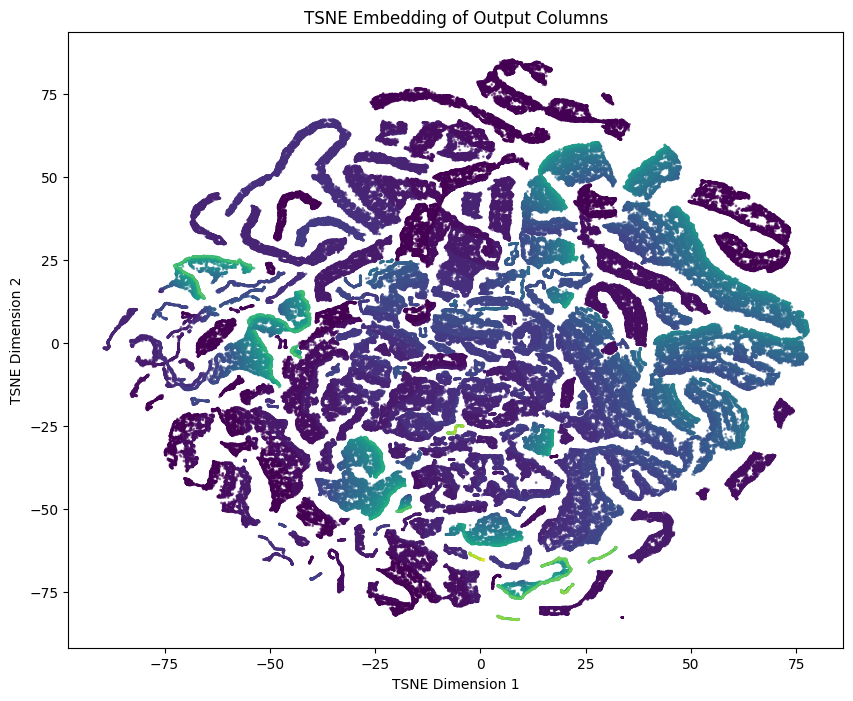

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=1, c=cleaned[input_cols[0]].values, alpha=0.5)
plt.title("TSNE Embedding of Output Columns")
plt.xlabel("TSNE Dimension 1")
plt.ylabel("TSNE Dimension 2")



In [18]:
dp_idxs = [10000, 1025]

n_samples = 256


inputs = cleaned[input_cols].values[dp_idxs]

interpolated_inputs = np.linspace(inputs[0], inputs[1], n_samples)

In [19]:
interpolated_inputs

array([[0.00000000e+00, 3.30000000e+00, 5.61000000e+01, 9.90000000e+00,
        9.90000000e+00, 2.08000000e+01],
       [0.00000000e+00, 3.28705882e+00, 5.59058824e+01, 9.88705882e+00,
        9.95176471e+00, 2.09682353e+01],
       [0.00000000e+00, 3.27411765e+00, 5.57117647e+01, 9.87411765e+00,
        1.00035294e+01, 2.11364706e+01],
       ...,
       [0.00000000e+00, 2.58823529e-02, 6.98823529e+00, 6.62588235e+00,
        2.29964706e+01, 6.33635294e+01],
       [0.00000000e+00, 1.29411765e-02, 6.79411765e+00, 6.61294118e+00,
        2.30482353e+01, 6.35317647e+01],
       [0.00000000e+00, 0.00000000e+00, 6.60000000e+00, 6.60000000e+00,
        2.31000000e+01, 6.37000000e+01]], shape=(256, 6))

In [20]:
outputs_interpolated = np.empty((n_samples, len(model_ensemble)))

for i, cm in enumerate(model_ensemble.items()):
    col, model = cm
    predictions = model.predict(interpolated_inputs)
    outputs_interpolated[:, i] = predictions
    

/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserW

In [21]:
outputs_interpolated
outputs_interpolated_df = pd.DataFrame(
    outputs_interpolated ,
    columns=output_cols,
)
outputs_interpolated_df

,Al,Si,Cu,Ni,Mg,Mn,Fe,Cr,Ti,Zr,...,Density(g/cm3),Volume(m3/mol),El.conductivity(S/m),El. resistivity(ohm m),heat capacity(J/(mol K)),Therm.conductivity(W/(mK)),Therm. diffusivity(m2/s),Therm.resistivity(mK/W),Linear thermal expansion (1/K)(20.0-300.0�C),Technical thermal expansion (1/K)(20.0-300.0�C)
0,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
1,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
2,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
3,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
4,93.933178,3.242918,0.450304,0.286270,0.833723,0.570248,0.357563,0.091002,0.042514,0.025061,...,2.668774,0.00001,1.347293e+07,7.425142e-08,27.686948,184.860041,0.000068,0.005408,0.000026,0.000024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
252,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
253,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023
254,88.461543,8.030735,0.777236,0.827256,0.785812,0.395022,0.537642,0.045295,0.026012,0.029167,...,2.671559,0.00001,1.222585e+07,8.196064e-08,27.515542,169.907281,0.000063,0.005894,0.000025,0.000023


In [22]:
# find closest points in the embedding space
from cuml.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(cleaned[output_cols].values)
distances, indices = nn.kneighbors(outputs_interpolated_df.values)

In [23]:
embeddings_nn= emb_tsne[indices.flatten()]

In [24]:
similarites=np.abs(cleaned[input_cols].values - inputs[0]).sum(axis=1)

In [25]:
similarites

array([158.4, 151.8, 145.2, ..., 191.4, 191.4, 198. ], shape=(324632,))

Text(0.5, 0, 'TNSE Dimension 1')

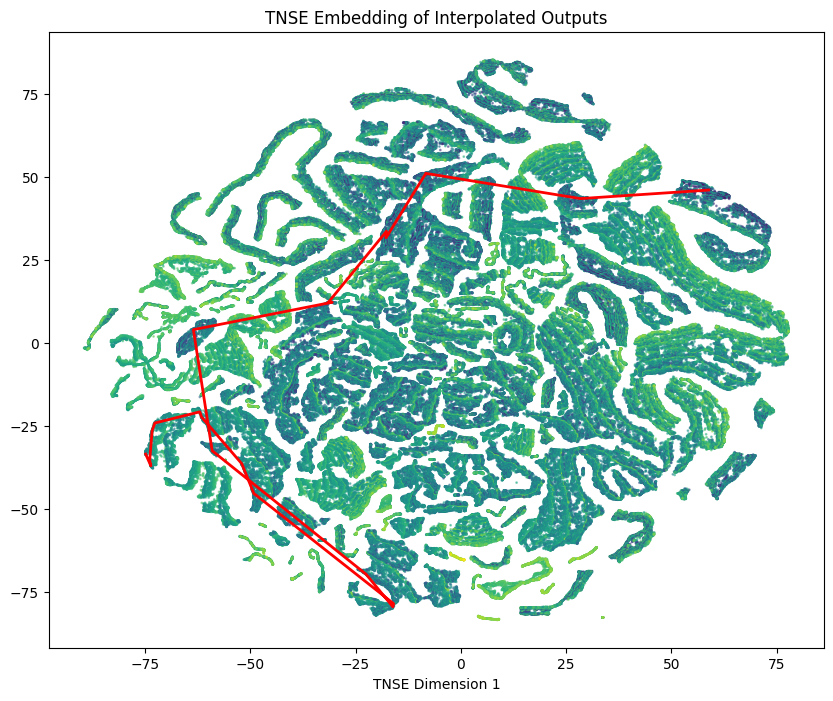

In [26]:
plt.figure(figsize=(10, 8))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=1, c=similarites, alpha=0.5)
plt.plot(embeddings_nn[:, 0], embeddings_nn[:, 1], color='red', linewidth=2)
plt.title("TNSE Embedding of Interpolated Outputs")
plt.xlabel("TNSE Dimension 1")

In [27]:
data

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136
0,0.0,0.0,0.0,0.0,0.0,100.0,83.675000,12.250000,0.900000,1.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,3.3,96.7,84.118850,11.865550,0.874425,1.257100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,6.6,93.4,84.562700,11.481100,0.848850,1.214200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,9.9,90.1,85.006550,11.096650,0.823275,1.171300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,13.2,86.8,85.450400,10.712200,0.797700,1.128400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324627,95.7,0.0,0.0,0.0,3.3,1.0,80.533928,12.296200,3.381765,1.946140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324628,95.7,0.0,0.0,3.3,0.0,1.0,80.539868,12.297322,3.397440,1.946140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324629,95.7,0.0,3.3,0.0,0.0,1.0,80.521553,12.309400,3.379290,1.946965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324630,95.7,3.3,0.0,0.0,0.0,1.0,80.358533,12.297025,3.531090,1.946965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
import torch as t
import torch.nn as nn
device = "cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu"
device

'cuda'

In [29]:
# VAE model
class VAE(nn.Module):
    def __init__(
        self,
        input_size=len(input_cols),
        layers=[128, 64, 32],
        norm=nn.BatchNorm1d,
        latent_size=16,
        out_norm=nn.BatchNorm1d,
    ):
        super(VAE, self).__init__()
        _layers = [input_size] + layers + [latent_size * 2]
        encoder_layers = []
        for i in range(len(_layers) - 1):
            in_size = _layers[i]
            out_size = _layers[i + 1]
            encoder_layers.append(nn.Linear(in_size, out_size))
            encoder_layers.append(nn.ReLU())
            if norm:
                encoder_layers.append(norm(out_size))
        self.encoder = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(layers[-1], latent_size)
        self.fc_logvar = nn.Linear(layers[-1], latent_size)
        decoder_layers = []
        out_layers =_layers[::-1]
        for i in range(len(out_layers) - 1):
            if i == 0:
                in_size = latent_size
            else:
                in_size = out_layers[i]
            out_size = out_layers[i + 1]
            decoder_layers.append(nn.Linear(in_size, out_size))
            decoder_layers.append(nn.ReLU())
            if norm:
                decoder_layers.append(norm(out_size))
        self.decoder = nn.Sequential(*decoder_layers)
        if out_norm is not None:
            self.out_norm = out_norm(input_size)
        else:
            self.out_norm = None

    def reparameterize(self, mu, logvar):
        std = t.exp(0.5 * logvar)
        eps = t.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = (
            h[..., : self.fc_mu.out_features],
            h[..., self.fc_mu.out_features :],
        )
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decoder(z)
        if self.out_norm is not None:
            x_reconstructed = self.out_norm(x_reconstructed)
        return x_reconstructed, mu, logvar

In [49]:
diff[diff == 0]

Series([], dtype: float64)

In [50]:
pd.isna(data_normed).sum().to_dict()

{'KS1295[%]': 0,
 '6082[%]': 0,
 '2024[%]': 0,
 'bat-box[%]': 0,
 '3003[%]': 0,
 '4032[%]': 0,
 'Al': 0,
 'Si': 0,
 'Cu': 0,
 'Ni': 0,
 'Mg': 0,
 'Mn': 0,
 'Fe': 0,
 'Cr': 0,
 'Ti': 0,
 'Zr': 0,
 'V': 0,
 'Zn': 0,
 'Vf_FCC_A1': 0,
 'Vf_DIAMOND_A4': 0,
 'Vf_AL15SI2M4': 0,
 'Vf_AL3X': 0,
 'Vf_AL6MN': 0,
 'Vf_MG2ZN3': 0,
 'Vf_AL3NI2': 0,
 'Vf_AL3NI_D011': 0,
 'Vf_AL7CU4NI': 0,
 'Vf_AL2CU_C16': 0,
 'Vf_Q_ALCUMGSI': 0,
 'Vf_AL7CU2FE': 0,
 'Vf_MG2SI_C1': 0,
 'Vf_AL9FE2SI2': 0,
 'Vf_AL18FE2MG7SI10': 0,
 'eut. frac.[%]': 0,
 'eut. T (�C)': 0,
 'T_FCC_A1': 0,
 'T_DIAMOND_A4': 0,
 'T_AL15SI2M4': 0,
 'T_AL3X': 0,
 'T_AL6MN': 0,
 'T_MG2ZN3': 0,
 'T_AL3NI2': 0,
 'T_AL3NI_D011': 0,
 'T_AL7CU4NI': 0,
 'T_AL2CU_C16': 0,
 'T_Q_ALCUMGSI': 0,
 'T_AL7CU2FE': 0,
 'T_MG2SI_C1': 0,
 'T_AL9FE2SI2': 0,
 'T_AL18FE2MG7SI10': 0,
 'T(liqu)': 0,
 'T(sol)': 0,
 'delta_T': 0,
 'delta_T_FCC': 0,
 'delta_T_Al15Si2M4': 0,
 'delta_T_Si': 0,
 'CSC': 0,
 'YS(MPa)': 0,
 'hardness(Vickers)': 0,
 'CTEvol(1/K)(20.0-300.0�C)': 

In [ ]:
import torch.utils.data as data_utils
from tqdm import tqdm
